In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
!mkdir -p "/content/drive/MyDrive/Plant-Disease-Detection"

In [21]:
!mkdir -p "/content/drive/MyDrive/Plant-Disease-Detection/data"

In [24]:
import os

if not os.path.exists("/content/drive/MyDrive/Plant-Disease-Detection/data/PlantVillage"):
    !unzip -o "/content/drive/MyDrive/Plant-Disease-Detection/data/archive.zip" -d "/content/drive/MyDrive/Plant-Disease-Detection/data/"
else:
    print("Dataset already extracted ✅")

Dataset already extracted ✅


In [25]:
!ls "/content/drive/MyDrive/Plant-Disease-Detection/data"

archive.zip  plantvillage  PlantVillage


In [26]:
import os

dataset_path = "/content/drive/MyDrive/Plant-Disease-Detection/data/PlantVillage"

classes = os.listdir(dataset_path)
print("Number of classes:", len(classes))
print(classes[:10])

Number of classes: 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot']


In [27]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [28]:
dataset_path = "/content/drive/MyDrive/Plant-Disease-Detection/data/PlantVillage"

In [29]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [30]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 16516 images belonging to 15 classes.


In [31]:
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 4122 images belonging to 15 classes.


In [11]:
# Build CNN Model

In [32]:
model = models.Sequential([

layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
layers.MaxPooling2D(2,2),

layers.Conv2D(64,(3,3),activation='relu'),
layers.MaxPooling2D(2,2),

layers.Conv2D(128,(3,3),activation='relu'),
layers.MaxPooling2D(2,2),

layers.Flatten(),

layers.Dense(256,activation='relu'),
layers.Dropout(0.5),

layers.Dense(15,activation='softmax')

])

In [34]:
model.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy']
)

In [35]:
import tensorflow as tf
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [36]:
history = model.fit(
train_data,
validation_data=val_data,
epochs=10
)

Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 137s 257ms/step - accuracy: 0.4335 - loss: 1.8073 - val_accuracy: 0.7671 - val_loss: 0.7141
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 118s 229ms/step - accuracy: 0.7487 - loss: 0.7660 - val_accuracy: 0.8663 - val_loss: 0.4071
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 120s 233ms/step - accuracy: 0.8204 - loss: 0.5383 - val_accuracy: 0.8738 - val_loss: 0.3692
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 116s 223ms/step - accuracy: 0.8615 - loss: 0.4134 - val_accuracy: 0.8896 - val_loss: 0.3234
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 116s 225ms/step - accuracy: 0.8967 - loss: 0.3029 - val_accuracy: 0.8760 - val_loss: 0.3834
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 121s 234ms/step - accuracy: 0.9060 - loss: 0.2763 - val_accuracy: 0.9047 - val_loss: 0.3100
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 121s 233ms/step - accuracy: 0.9240 - loss: 0.2287 - val_accuracy: 0.8792 - val_loss: 0.3732
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 118s 228ms/step - accuracy: 0.9289 -

In [37]:
model.save('/content/drive/MyDrive/Plant-Disease-Detection/models/plant_disease_model.h5')

In [41]:
import os

os.makedirs('/content/drive/MyDrive/Plant-Disease-Detection/images', exist_ok=True)

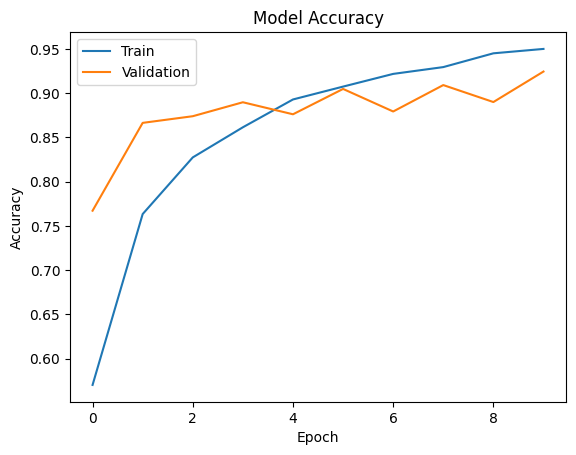

In [42]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.savefig('/content/drive/MyDrive/Plant-Disease-Detection/images/accuracy_graph.png')

plt.show()

In [43]:
!ls /content/drive/MyDrive/Plant-Disease-Detection/images

accuracy_graph.png


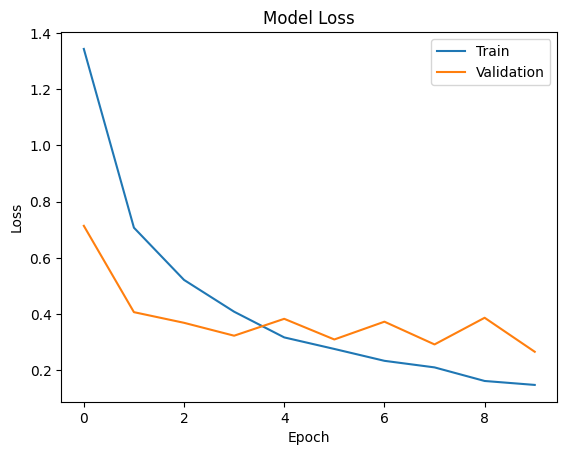

In [46]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.savefig('/content/drive/MyDrive/Plant-Disease-Detection/images/loss_graph.png')
plt.show()

In [52]:
!ls /content/drive/MyDrive/Plant-Disease-Detection/data/PlantVillage

Pepper__bell___Bacterial_spot  Tomato_Late_blight
Pepper__bell___healthy	       Tomato_Leaf_Mold
Potato___Early_blight	       Tomato_Septoria_leaf_spot
Potato___healthy	       Tomato_Spider_mites_Two_spotted_spider_mite
Potato___Late_blight	       Tomato__Target_Spot
Tomato_Bacterial_spot	       Tomato__Tomato_mosaic_virus
Tomato_Early_blight	       Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato_healthy


In [55]:
import os

base_path = "/content/drive/MyDrive/Plant-Disease-Detection"

folders = ["app", "models", "notebooks", "src", "test_images", "images"]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [56]:
!ls /content/drive/MyDrive/Plant-Disease-Detection

app  data  images  models  notebooks  src  test_images


In [61]:
import os

os.makedirs('/content/drive/MyDrive/Plant-Disease-Detection/results', exist_ok=True)
os.makedirs('/content/drive/MyDrive/Plant-Disease-Detection/results/predictions', exist_ok=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Saved at: /content/drive/MyDrive/Plant-Disease-Detection/results/predictions/prediction1.png


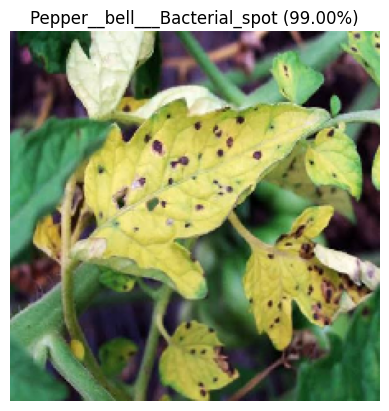

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

class_names = [
"Pepper__bell___Bacterial_spot",
"Pepper__bell___healthy",
"Potato___Early_blight",
"Potato___healthy",
"Potato___Late_blight",
"Tomato_Bacterial_spot",
"Tomato_Early_blight",
"Tomato_Late_blight",
"Tomato_Leaf_Mold",
"Tomato_Septoria_leaf_spot",
"Tomato_Spider_mites_Two_spotted_spider_mite",
"Tomato__Target_Spot",
"Tomato__Tomato_mosaic_virus",
"Tomato__Tomato_YellowLeaf__Curl_Virus",
"Tomato_healthy"
]

img_path = '/content/drive/MyDrive/Plant-Disease-Detection/test_images/test_img.jpeg'

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = np.max(prediction)*100

plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis("off")

save_path = "/content/drive/MyDrive/Plant-Disease-Detection/results/predictions/prediction1.png"
plt.savefig(save_path)

print("Saved at:", save_path)

In [63]:
!pip install seaborn

129/129 ━━━━━━━━━━━━━━━━━━━━ 20s 152ms/step


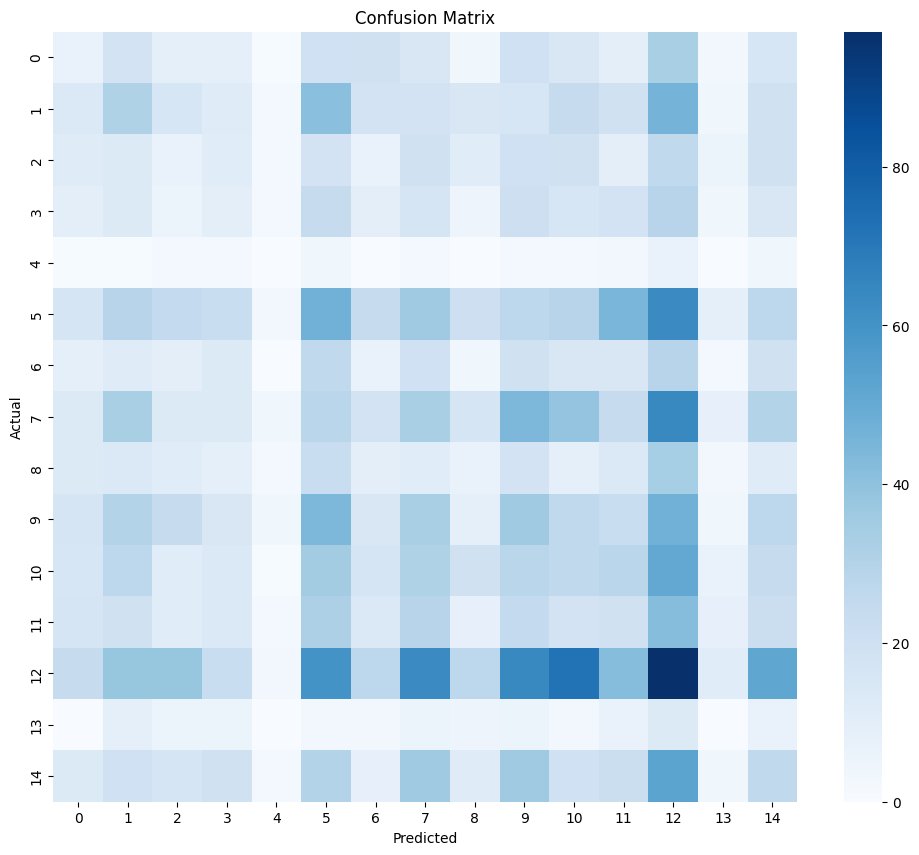

In [65]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("/content/drive/MyDrive/Plant-Disease-Detection/results/confusion_matrix.png")

plt.show()

Classification Report

In [66]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
)

print(report)

with open("/content/drive/MyDrive/Plant-Disease-Detection/results/classification_report.txt","w") as f:
    f.write(report)

print("Report saved successfully")

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.04      0.04      0.04       199
                     Pepper__bell___healthy       0.10      0.11      0.10       295
                      Potato___Early_blight       0.03      0.04      0.03       200
                           Potato___healthy       0.05      0.05      0.05       200
                       Potato___Late_blight       0.00      0.00      0.00        30
                      Tomato_Bacterial_spot       0.11      0.11      0.11       425
                        Tomato_Early_blight       0.04      0.04      0.04       200
                         Tomato_Late_blight       0.09      0.09      0.09       381
                           Tomato_Leaf_Mold       0.04      0.04      0.04       190
                  Tomato_Septoria_leaf_spot       0.09      0.10      0.10       354
Tomato_Spider_mites_Two_spotted_spider_mite       0.08      0.08

Prediction for Multiple Images (Batch Prediction)


In [67]:
import os
from tensorflow.keras.preprocessing import image
import numpy as np

test_folder = "/content/drive/MyDrive/Plant-Disease-Detection/test_images"

results_file = open("/content/drive/MyDrive/Plant-Disease-Detection/results/batch_predictions.txt","w")

for img_name in os.listdir(test_folder):

    img_path = os.path.join(test_folder, img_name)

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)*100

    result = f"{img_name} → {predicted_class} ({confidence:.2f}%)"

    print(result)
    results_file.write(result+"\n")

results_file.close()

print("Batch predictions saved!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
test_img.jpeg → Pepper__bell___Bacterial_spot (99.00%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
img1.jpeg → Tomato_Septoria_leaf_spot (61.32%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
img3.jpeg → Tomato_Late_blight (100.00%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
img2.jpeg → Tomato_Septoria_leaf_spot (63.68%)
Batch predictions saved!
